Cell 1 — Imports & Setup

In [31]:
import os, random, shutil, argparse, numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


Cell 2 — Dataset Split Function

In [32]:
def split_dataset(data_dir, output_dir, seed=42):
    random.seed(seed)
    os.makedirs(output_dir, exist_ok=True)
    pairs = []

    for class_name, sub_dirs in [("bleeding", ("Images","Annotations")), ("non-bleeding", ("images","annotation"))]:
        img_dir = os.path.join(data_dir, class_name, sub_dirs[0])
        mask_dir = os.path.join(data_dir, class_name, sub_dirs[1])
        for f in os.listdir(img_dir):
            if f.lower().endswith(".png"):
                mask_path = os.path.join(mask_dir, f.replace("img-", "ann-"))
                if os.path.exists(mask_path):
                    pairs.append((os.path.join(img_dir, f), mask_path))

    random.shuffle(pairs)
    n = len(pairs)
    n_train = int(0.7*n)
    n_val = int(0.2*n)
    train = pairs[:n_train]
    val = pairs[n_train:n_train+n_val]
    test = pairs[n_train+n_val:]

    for split, items in [("train",train),("val",val),("test",test)]:
        img_out = os.path.join(output_dir, split, "images")
        mask_out = os.path.join(output_dir, split, "masks")
        os.makedirs(img_out, exist_ok=True)
        os.makedirs(mask_out, exist_ok=True)
        for img_src, mask_src in items:
            shutil.copy(img_src, os.path.join(img_out, os.path.basename(img_src)))
            shutil.copy(mask_src, os.path.join(mask_out, os.path.basename(mask_src)))

    print(f"Split done. train={len(train)} val={len(val)} test={len(test)}")


Cell 3 — Dataset Loader

In [33]:
class WCEBleedDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None, img_size=128):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(".png")])
        self.transform = transform
        self.img_size = img_size

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img_path = os.path.join(self.images_dir, fname)
        mask_path = os.path.join(self.masks_dir, fname.replace("img-", "ann-"))

        img = np.array(Image.open(img_path).convert("RGB").resize((self.img_size,self.img_size)))
        mask = np.array(Image.open(mask_path).convert("L").resize((self.img_size,self.img_size)))
        mask = (mask>127).astype(np.uint8)
        cls_label = int(mask.sum() > 0)

        if self.transform:
            transformed = self.transform(image=img, mask=mask)
            img_t = transformed["image"]
            mask_t = transformed["mask"].unsqueeze(0).float()
        else:
            img_t = torch.from_numpy(img).permute(2,0,1).float()/255.0
            mask_t = torch.from_numpy(mask).unsqueeze(0).float()

        return img_t, mask_t, torch.tensor(cls_label, dtype=torch.long), fname


Cell 4 — ResNet + U-Net Model

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class ResNetUNet(nn.Module):
    def __init__(self, n_classes=1, pretrained=True, dropout_p=0.3):
        super().__init__()
        self.n_classes = n_classes
        self.dropout_p = dropout_p

        # --- Encoder (ResNet34) ---
        resnet = models.resnet34(pretrained=pretrained)
        self.encoder_layers = list(resnet.children())
        self.enc1 = nn.Sequential(*self.encoder_layers[:3])   # conv1+bn+relu
        self.enc2 = nn.Sequential(*self.encoder_layers[3:5])  # layer1
        self.enc3 = self.encoder_layers[5]  # layer2
        self.enc4 = self.encoder_layers[6]  # layer3
        self.enc5 = self.encoder_layers[7]  # layer4

        # --- Decoder ---
        self.up5 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec5 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_p)
        )

        self.up4 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec4 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_p)
        )

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_p)
        )

        self.up2 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_p)
        )

        self.seg_out = nn.Conv2d(64, n_classes, kernel_size=1)

        # --- Classification head ---
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc_cls = nn.Linear(512, 2)  # binary classification (Bleed / Non-Bleed)

    def forward(self, x):
        # --- Encoder ---
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        # --- Decoder ---
        d5 = self.up5(e5)
        d5 = torch.cat([d5, e4], dim=1)
        d5 = self.dec5(d5)

        d4 = self.up4(d5)
        d4 = torch.cat([d4, e3], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e2], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.dec2(d2)

        seg_logits = self.seg_out(d2)

        # --- Classification ---
        cls_feat = self.avgpool(e5)
        cls_feat = torch.flatten(cls_feat,1)
        cls_logits = self.fc_cls(cls_feat)

        return seg_logits, cls_logits


Cell 5 — Dataset and its loader

In [35]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

class WCEBleedDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_files = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.lower().endswith((".png", ".PNG"))])
        self.mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.lower().endswith((".png", ".PNG"))])
        self.transform = transform

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.img_files[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_files[idx]).convert("L"))
        cls_label = 1 if mask.sum() > 0 else 0  # 1 if bleed exists

        # Normalize mask to [0,1]
        mask = mask / 255.0

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"].unsqueeze(0).float()
        else:
            img = torch.tensor(img).permute(2,0,1).float()/255.0
            mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask, torch.tensor(cls_label, dtype=torch.long)

# --- Example transforms ---
transform = A.Compose([
    A.Resize(128,128),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# --- Datasets and loaders ---
train_ds = WCEBleedDataset("dataset_split/train/images", "dataset_split/train/masks", transform)
val_ds   = WCEBleedDataset("dataset_split/val/images", "dataset_split/val/masks", transform)

from torch.utils.data import DataLoader
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False)

# --- Device ---
device = "cuda" if torch.cuda.is_available() else "cpu"


Cell 6 — Training & Evaluation

In [36]:
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import os

# --- Model ---
# Replace ResNetUNet() with your model class
model = ResNetUNet().to(device)
# Random weight initialization
def init_weights(m):
    if isinstance(m, (torch.nn.Conv2d, torch.nn.Linear)):
        torch.nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)
model.apply(init_weights)

# --- Losses and optimizer ---
loss_seg = torch.nn.BCEWithLogitsLoss()
loss_cls = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)  # L2 regularization

# --- Training parameters ---
epochs = 30
patience = 5
best_val_loss = float("inf")
early_stop_counter = 0
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

train_losses, val_losses = [], []

for epoch in range(epochs):
    # --- Train ---
    model.train()
    total_loss = 0
    for imgs, masks, cls in train_loader:
        imgs, masks, cls = imgs.to(device), masks.to(device), cls.to(device)
        optimizer.zero_grad()
        seg_logits, cls_logits = model(imgs)

        # Fix shape mismatch
        if seg_logits.shape != masks.shape:
            seg_logits = F.interpolate(seg_logits, size=masks.shape[2:], mode="bilinear", align_corners=False)

        loss = loss_seg(seg_logits, masks) + loss_cls(cls_logits, cls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)

    train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # --- Validate ---
    model.eval()
    total_val_loss = 0
    all_cls_true, all_cls_pred, all_cls_probs = [], [], []
    all_seg_true, all_seg_pred = [], []

    with torch.no_grad():
        for imgs, masks, cls in val_loader:
            imgs, masks, cls = imgs.to(device), masks.to(device), cls.to(device)
            seg_logits, cls_logits = model(imgs)

            if seg_logits.shape != masks.shape:
                seg_logits = F.interpolate(seg_logits, size=masks.shape[2:], mode="bilinear", align_corners=False)

            loss = loss_seg(seg_logits, masks) + loss_cls(cls_logits, cls)
            total_val_loss += loss.item() * imgs.size(0)

            # Classification metrics
            all_cls_true.extend(cls.cpu().numpy())
            preds = torch.argmax(cls_logits, dim=1)
            all_cls_pred.extend(preds.cpu().numpy())
            probs = torch.softmax(cls_logits, dim=1)[:,1]
            all_cls_probs.extend(probs.cpu().numpy())

            # Segmentation metrics
            all_seg_true.extend(masks.cpu().numpy().reshape(len(masks),-1))
            all_seg_pred.extend((torch.sigmoid(seg_logits).cpu().numpy().reshape(len(masks),-1) > 0.5).astype(np.uint8))

    val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    # --- Metrics ---
    precision = precision_score(all_cls_true, all_cls_pred, zero_division=0)
    recall = recall_score(all_cls_true, all_cls_pred, zero_division=0)
    f1 = f1_score(all_cls_true, all_cls_pred, zero_division=0)
    accuracy = accuracy_score(all_cls_true, all_cls_pred)

    all_seg_true_np = np.array(all_seg_true)
    all_seg_pred_np = np.array(all_seg_pred)
    dice = (2*(all_seg_true_np*all_seg_pred_np).sum(axis=1)/((all_seg_true_np+all_seg_pred_np).sum(axis=1)+1e-6)).mean()
    iou  = ((all_seg_true_np*all_seg_pred_np).sum(axis=1)/((all_seg_true_np+all_seg_pred_np-all_seg_true_np*all_seg_pred_np).sum(axis=1)+1e-6)).mean()

    print(f"\n=== Epoch {epoch+1}/{epochs} ===")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | Accuracy: {accuracy:.4f}")
    print(f"Mean Dice Score: {dice:.4f} | Mean IoU: {iou:.4f}")

    # --- Early stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), os.path.join(output_dir,"best_model.pth"))
    else:
        early_stop_counter +=1
        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break


c:\Users\aditi\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aditi\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== Epoch 1/30 ===
Train Loss: 1.0268 | Val Loss: 0.9395
Precision: 0.9519 | Recall: 0.4091 | F1: 0.5723 | Accuracy: 0.6878
Mean Dice Score: 0.1785 | Mean IoU: 0.1323

=== Epoch 2/30 ===
Train Loss: 0.8471 | Val Loss: 0.8469
Precision: 0.8520 | Recall: 0.6901 | F1: 0.7626 | Accuracy: 0.7806
Mean Dice Score: 0.1964 | Mean IoU: 0.1520

=== Epoch 3/30 ===
Train Loss: 0.7153 | Val Loss: 1.0442
Precision: 0.8607 | Recall: 0.7149 | F1: 0.7810 | Accuracy: 0.7954
Mean Dice Score: 0.2221 | Mean IoU: 0.1734

=== Epoch 4/30 ===
Train Loss: 0.6562 | Val Loss: 1.2622
Precision: 0.8795 | Recall: 0.8140 | F1: 0.8455 | Accuracy: 0.8481
Mean Dice Score: 0.1935 | Mean IoU: 0.1472

=== Epoch 5/30 ===
Train Loss: 0.5353 | Val Loss: 0.4750
Precision: 0.9254 | Recall: 0.8719 | F1: 0.8979 | Accuracy: 0.8987
Mean Dice Score: 0.1920 | Mean IoU: 0.1449

=== Epoch 6/30 ===
Train Loss: 0.4824 | Val Loss: 0.3740
Precision: 0.9689 | Recall: 0.9008 | F1: 0.9336 | Accuracy: 0.9346
Mean Dice Score: 0.2053 | Mean IoU:

Cell-7 The Plots

C:\Users\aditi\AppData\Local\Temp\ipykernel_15440\2064641750.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locati

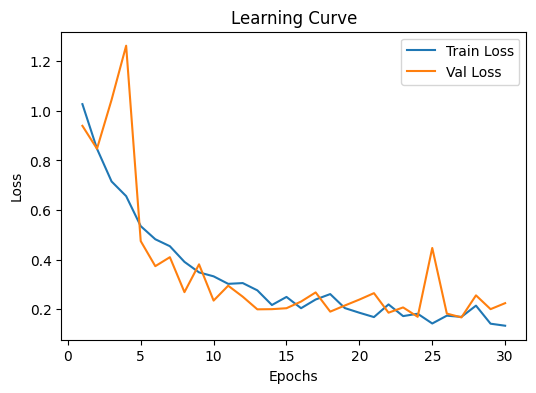

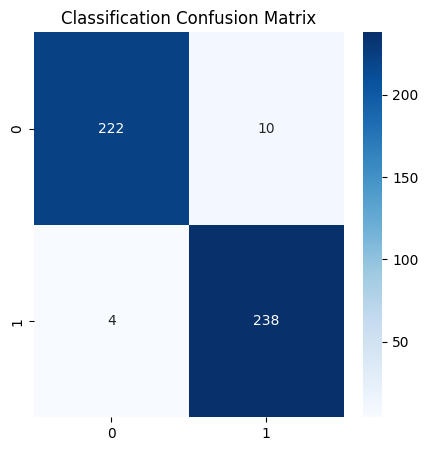

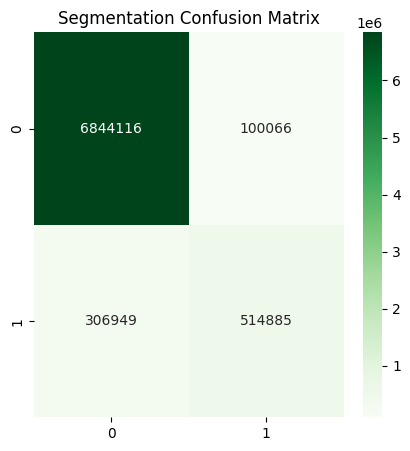

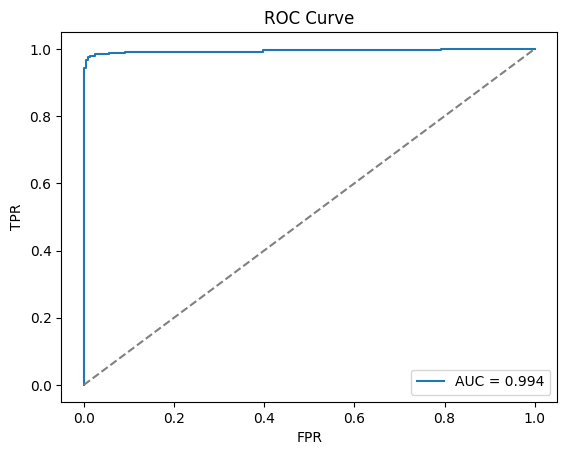

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import os
import numpy as np

# --- Load best model ---
best_model_path = os.path.join(output_dir,"best_model.pth")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# --- Classification & Segmentation metrics already computed ---
cm_cls = confusion_matrix(all_cls_true, all_cls_pred)
cm_seg = confusion_matrix(np.array(all_seg_true).flatten(), np.array(all_seg_pred).flatten())

# --- Plots ---
# Loss curve
plt.figure(figsize=(6,4))
plt.plot(range(1,len(train_losses)+1), train_losses, label="Train Loss")
plt.plot(range(1,len(val_losses)+1), val_losses, label="Val Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Learning Curve")
plt.savefig(os.path.join(output_dir,"learning_loss_curve.PNG"))
plt.show()

# Classification confusion matrix
plt.figure(figsize=(5,5))
sns.heatmap(cm_cls, annot=True, fmt="d", cmap="Blues")
plt.title("Classification Confusion Matrix")
plt.savefig(os.path.join(output_dir,"cls_confusion_matrix.PNG"))
plt.show()

# Segmentation confusion matrix
plt.figure(figsize=(5,5))
sns.heatmap(cm_seg, annot=True, fmt="d", cmap="Greens")
plt.title("Segmentation Confusion Matrix")
plt.savefig(os.path.join(output_dir,"seg_confusion_matrix.PNG"))
plt.show()

# ROC-AUC curve
fpr, tpr, _ = roc_curve(all_cls_true, all_cls_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.title("ROC Curve")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()
plt.savefig(os.path.join(output_dir,"roc_curve.PNG"))
plt.show()
